In [62]:
import math
import random
import json
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Для нормализации данных и расчета метрик
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge

# PyTorch для построения и обучения нейросетей
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Настройка визуализации и вывода
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(19)

# Определяем устройство: используем GPU если доступен, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### Данные и первичный анализ

In [3]:
df = pd.read_csv('data/S12-hw-dataset.csv')
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [4]:
# Привести колонку date к datetime и отсортировать по времени
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

In [5]:
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [6]:
print("Число наблюдений:", len(df))
print("Диапазон дат:", df['date'].min(), "–", df['date'].max())
print("\nЧисло пропусков по колонкам:")
print(df.isna().sum())

Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 – 2025-06-29 23:00:00

Число пропусков по колонкам:
date      0
target    0
dtype: int64


,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:29:59.999999744,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


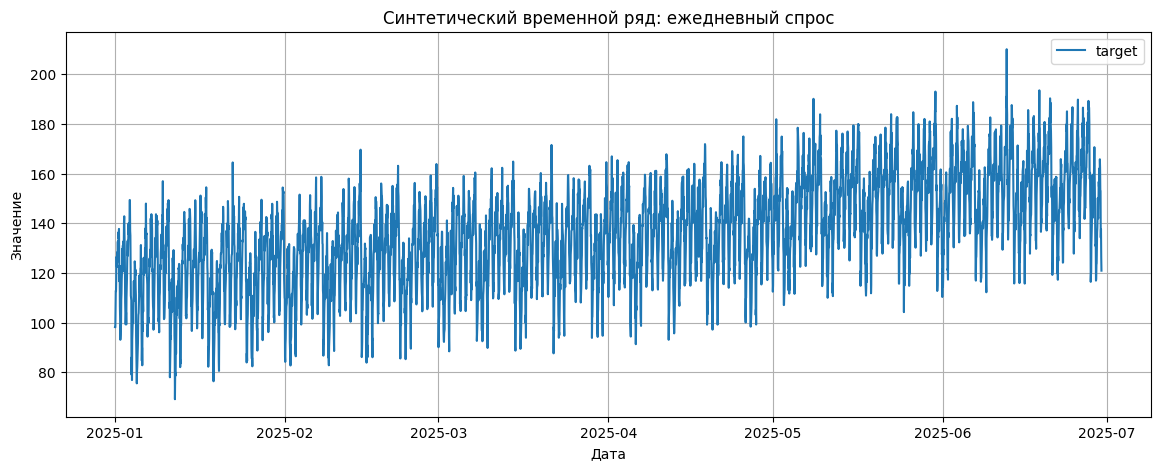

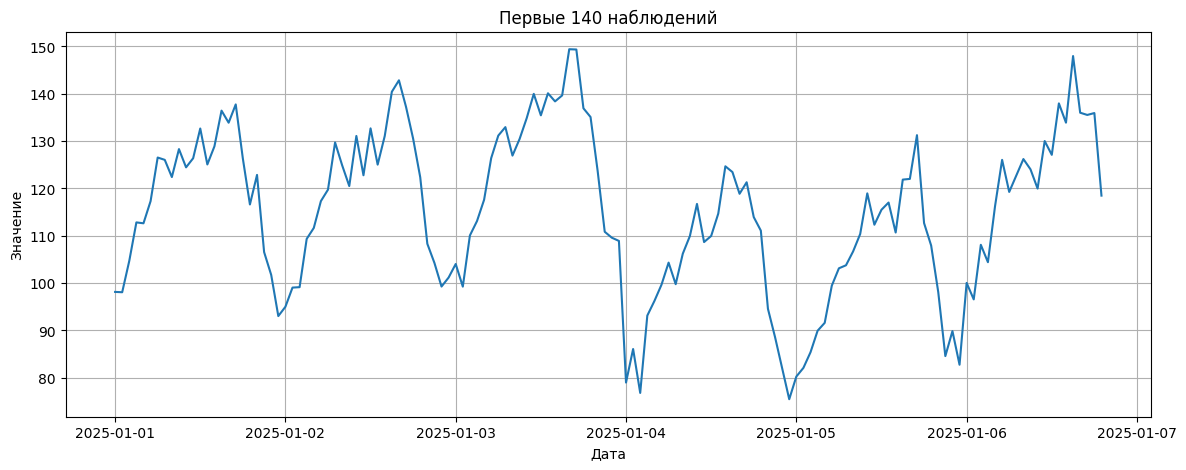

In [7]:
display(df.describe(include="all").T)

fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.5, label="target")
ax.set_title("Синтетический временной ряд: ежедневный спрос")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(df["date"].iloc[:140], df["target"].iloc[:140], lw=1.5)
ax.set_title("Первые 140 наблюдений")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
plt.show()

Временной ряд target имеет возрастающий падающий тренд, видимые недельные циклы указывают на сезонность. В ряде наблюдаются отдельные выбросы, которые могут влиять на модели. Поведение дисперсии и среднего во времени указывает на нестационарность, поэтому для моделирования будут целесообразны дифференцирование или стационарные спецификации.

### Корректный temporal split

In [8]:
# Random split некорректен в случае временных рядов, поскольку для временного ряда мы обязаны сохранять хронологический порядок: 
# модель должна учиться на прошлом и проверяться на будущем.

@dataclass
class SplitConfig:
    train_frac: float = 0.70  # 70% для обучения
    val_frac: float = 0.15    # 15% для валидации, остальное для теста

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()          # Ранний период
    val_df = df.iloc[train_end:val_end].copy()     # Средний период
    test_df = df.iloc[val_end:].copy()             # Поздний период
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df.shape}, {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"val  : {val_df.shape}, {val_df['date'].min().date()} -> {val_df['date'].max().date()}")
print(f"test : {test_df.shape}, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

train: (3024, 2), 2025-01-01 -> 2025-05-06
val  : (648, 2), 2025-05-07 -> 2025-06-02
test : (648, 2), 2025-06-03 -> 2025-06-29


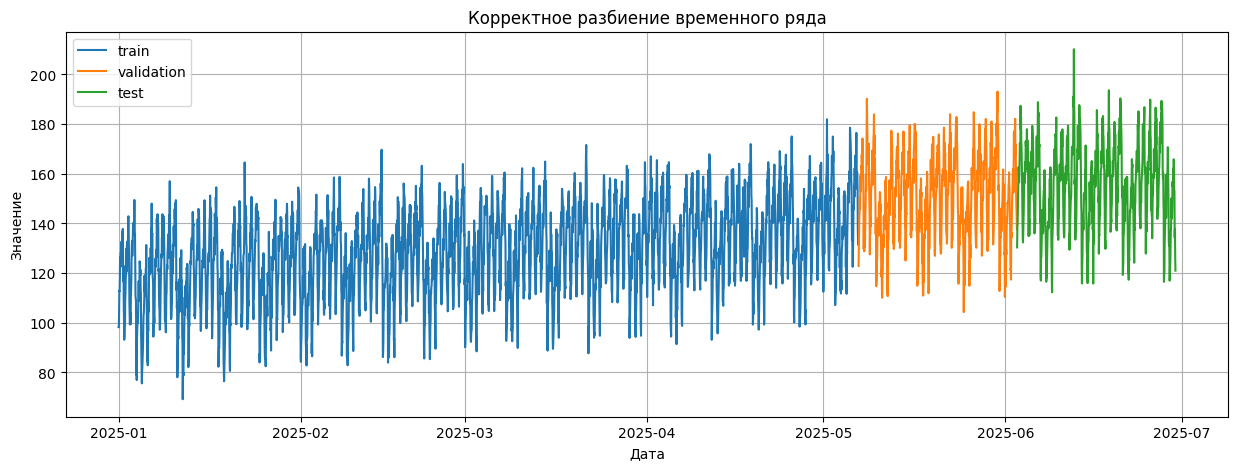

In [9]:
# визуализация разбиения
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректное разбиение временного ряда")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig("artifacts/figures/series_split.png")

Random split некорректен в случае временных рядов, поскольку для временного ряда мы обязаны сохранять хронологический порядок: модель должна учиться на прошлом и проверяться на будущем.

### Признаки для baseline-моделей

In [40]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"]      = out["date"].dt.month
    # hour - если нужен (для почасовых данных)
    out["hour"]       = out["date"].dt.hour

    # День недели (цикличность)
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    # Месяц (цикличность)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)

    # Час (цикличность, по желанию)
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)

    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    # Лаги смотрят только назад во времени и поэтому безопасны с точки зрения leakage.
    out["lag_1"] = out[target_col].shift(1)
    out["lag_7"] = out[target_col].shift(7)
    out["lag_14"] = out[target_col].shift(14)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    return out

In [41]:
feature_cols = [
    # календарные
    "dayofweek", "month", "hour",
    # лаги и rolling
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
]

target_col = "target"

In [43]:
features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()

,date,target,dayofweek,month,hour,dow_sin,dow_cos,month_sin,month_cos,hour_sin,hour_cos,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2025-01-01 14:00:00,128.87,2,1,14,0.974928,-0.222521,0.5,0.866025,-0.500000,-8.660254e-01,125.04,126.01,98.14,126.445714,3.275621
1,2025-01-01 15:00:00,136.40,2,1,15,0.974928,-0.222521,0.5,0.866025,-0.707107,-7.071068e-01,128.87,122.38,98.07,126.854286,3.388632
2,2025-01-01 16:00:00,133.85,2,1,16,0.974928,-0.222521,0.5,0.866025,-0.866025,-5.000000e-01,136.40,128.28,104.70,128.857143,4.318919
3,2025-01-01 17:00:00,137.71,2,1,17,0.974928,-0.222521,0.5,0.866025,-0.965926,-2.588190e-01,133.85,124.43,112.81,129.652857,4.691868
4,2025-01-01 18:00:00,126.32,2,1,18,0.974928,-0.222521,0.5,0.866025,-1.000000,-1.836970e-16,137.71,126.35,112.62,131.550000,4.907936


In [44]:
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (3014, 8) | y_train: (3014,)
X_val:   (646, 8) | y_val:   (646,)
X_test:  (646, 8) | y_test:  (646,)


### Оконное представление для GRU

In [30]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

In [46]:
window_size = 70  # глубина окна, можно менять

def make_windows(series_2d: np.ndarray, window_size: int):
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train2, y_train2 = make_windows(train_scaled, window_size)
X_val2, y_val2 = make_windows(val_scaled, window_size)
X_test2, y_test2 = make_windows(test_scaled, window_size)

print("X_train:", X_train2.shape, "y_train:", y_train2.shape)
print("X_val  :", X_val2.shape, "y_val  :", y_val2.shape)
print("X_test :", X_test2.shape, "y_test :", y_test2.shape)

X_train: (2954, 70, 1) y_train: (2954,)
X_val  : (578, 70, 1) y_val  : (578,)
X_test : (578, 70, 1) y_test : (578,)


Форма одного окна: (70, 1)
Первые 5 значений окна: [-1.6267993  -1.6305869  -1.2718506  -0.8330344  -0.84331495]
Цель: -1.0078033


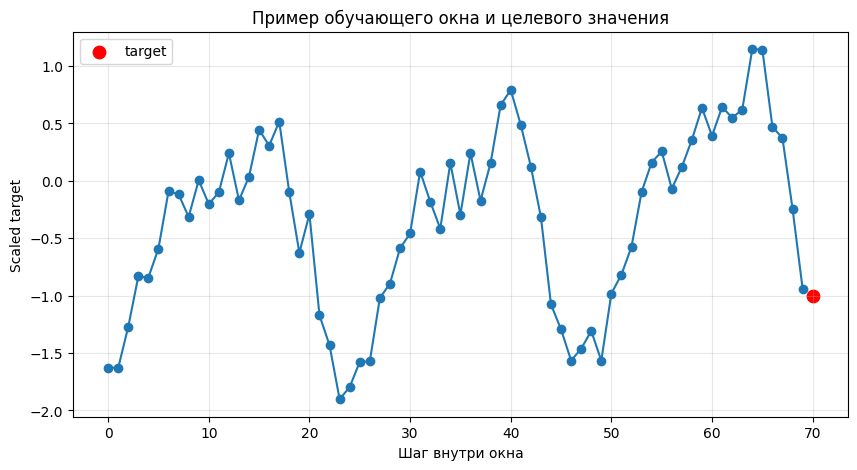

In [49]:
sample_idx = 0

print("Форма одного окна:", X_train2[sample_idx].shape)
print("Первые 5 значений окна:", X_train2[sample_idx][:5].ravel())
print("Цель:", y_train2[sample_idx])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(window_size), X_train2[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train2[sample_idx]], s=80, c="red", label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled target")
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [51]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (N,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]  # (window_size, 1), float

batch_size = 64

train_ds = TimeSeriesDataset(X_train2, y_train2)
val_ds   = TimeSeriesDataset(X_val2,   y_val2)
test_ds  = TimeSeriesDataset(X_test2,  y_test2)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

# Проверка формы батча
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)


Batch X: torch.Size([64, 70, 1])
Batch y: torch.Size([64])


### Базовые функции обучения и оценки

In [52]:
def train_one_epoch(model, loader, optimizer, criterion, device): # Обучает модель на одной эпохе.
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device): # Оценивает модель на валидации/тесте без обновления весов.
    model.eval()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device): #  Полный цикл обучения с ранней остановкой.
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

# Небольшие вспомогательные функции для единообразной оценки всех моделей.
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])

## Обязательные эксперименты

In [53]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100  # +epsilon чтобы избежать деления на 0
    return {
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
    }


def append_run_to_csv(run: dict, csv_path: str = "artifacts/runs.csv"):
    run_df = pd.DataFrame([run])
    if os.path.exists(csv_path):
        existing = pd.read_csv(csv_path)
        run_df = pd.concat([existing, run_df], ignore_index=True)
    run_df.to_csv(csv_path, index=False)

### B1: naive-last

In [54]:
val_pred_naive = val_feat["lag_1"].to_numpy()
test_pred_naive = test_feat["lag_1"].to_numpy()

b1_val = evaluate_regression(y_val, val_pred_naive, "Naive (lag_1)")

display(b1_val)

,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.443406,8.203532,4.394594


In [63]:
print("=== ПРОВЕРКА ЛАГОВ ===")
print("val_feat колонки с 'lag':", [c for c in val_feat.columns if 'lag' in c])
print("val_feat lag_7:", val_feat.get('lag_7', ' ОТСУТСТВУЕТ'))
print("val_feat lag_14:", val_feat.get('lag_14', ' ОТСУТСТВУЕТ'))
print("\nfeature_cols:", feature_cols)
print("lag_7 в feature_cols:", 'lag_7' in feature_cols)
print("lag_14 в feature_cols:", 'lag_14' in feature_cols)

=== ПРОВЕРКА ЛАГОВ ===
val_feat колонки с 'lag': ['lag_1', 'lag_7', 'lag_14']
val_feat lag_7: 3014    137.35
3015    131.33
3016    133.29
3017    122.76
3018    129.46
         ...  
3655    176.55
3656    177.95
3657    182.07
3658    167.03
3659    171.71
Name: lag_7, Length: 646, dtype: float64
val_feat lag_14: 3014    166.58
3015    176.40
3016    163.32
3017    153.98
3018    160.61
         ...  
3655    161.91
3656    161.94
3657    152.32
3658    164.73
3659    176.92
Name: lag_14, Length: 646, dtype: float64

feature_cols: ['dayofweek', 'month', 'hour', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7']
lag_7 в feature_cols: True
lag_14 в feature_cols: True


In [66]:
# Naive модели с разными лагами
naive_models = {
    "Naive (lag_1)":  val_feat["lag_1"].to_numpy(),
    "Naive (lag_7)":  val_feat["lag_7"].to_numpy(), 
    "Naive (lag_14)": val_feat["lag_14"].to_numpy()
}

for name, pred in naive_models.items():
    eval_result = evaluate_regression(y_val, pred, name)
    rmse_value = eval_result['RMSE'].iloc[0]
    
    print(f"{name:15} | NaN: {np.isnan(pred).sum():3d} | RMSE: {rmse_value:.3f}")
    display(eval_result)

Naive (lag_1)   | NaN:   0 | RMSE: 8.204


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.443406,8.203532,4.394594


Naive (lag_7)   | NaN:   0 | RMSE: 24.341


,model,MAE,RMSE,MAPE_%
0,Naive (lag_7),20.862647,24.340902,14.516947


Naive (lag_14)  | NaN:   0 | RMSE: 27.570


,model,MAE,RMSE,MAPE_%
0,Naive (lag_14),23.714009,27.57036,15.994973


### B2: moving-average

In [67]:
# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()

b2_val = evaluate_regression(y_val, val_pred_ma7, "MovingAverage(7)")

display(b2_val)

,model,MAE,RMSE,MAPE_%
0,MovingAverage(7),12.723717,15.236326,8.828779


### B3: Ridge на lag/rolling/календарных признаках

In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [69]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [70]:
val_pred_ridge = ridge.predict(X_val_scaled)

In [71]:
b3_val = evaluate_regression(y_val, val_pred_ridge, "Ridge")
display(b3_val)

,model,MAE,RMSE,MAPE_%
0,Ridge,5.990878,7.533349,4.039373


In [74]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'weight': ridge.coef_
}).sort_values('weight', key=abs, ascending=False)

print("Веса Ridge:")
for _, row in feature_importance.iterrows():
    lag_mark = "ЛАГ" if 'lag' in row['feature'] else ""
    print(f"{row['feature']:15} | вес: {row['weight']:+.4f} {lag_mark}")

Веса Ridge:
lag_1           | вес: +13.8177 ЛАГ
hour            | вес: -3.4218 
rolling_mean_7  | вес: +3.3845 
lag_7           | вес: -2.6978 ЛАГ
rolling_std_7   | вес: -2.0420 
month           | вес: +1.7021 
dayofweek       | вес: -1.3329 
lag_14          | вес: -1.1202 ЛАГ


###  R1: GRU на оконном представлении

In [75]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

In [76]:
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01 | train_loss=0.7010 | val_loss=0.5316
Epoch 02 | train_loss=0.4154 | val_loss=0.2807
Epoch 03 | train_loss=0.2177 | val_loss=0.1730
Epoch 04 | train_loss=0.1721 | val_loss=0.1548
Epoch 05 | train_loss=0.1608 | val_loss=0.1521
Epoch 06 | train_loss=0.1568 | val_loss=0.1518
Epoch 07 | train_loss=0.1547 | val_loss=0.1524
Epoch 08 | train_loss=0.1533 | val_loss=0.1534
Epoch 09 | train_loss=0.1521 | val_loss=0.1544
Epoch 10 | train_loss=0.1510 | val_loss=0.1553
Epoch 11 | train_loss=0.1498 | val_loss=0.1560
Epoch 12 | train_loss=0.1482 | val_loss=0.1562
Epoch 13 | train_loss=0.1461 | val_loss=0.1556
Epoch 14 | train_loss=0.1425 | val_loss=0.1526
Epoch 15 | train_loss=0.1355 | val_loss=0.1418
Epoch 16 | train_loss=0.1228 | val_loss=0.1234
Epoch 17 | train_loss=0.1133 | val_loss=0.1215
Epoch 18 | train_loss=0.1091 | val_loss=0.1186
Epoch 19 | train_loss=0.1071 | val_loss=0.1157
Epoch 20 | train_loss=0.1055 | val_loss=0.1134
Epoch 21 | train_loss=0.1041 | val_loss=0

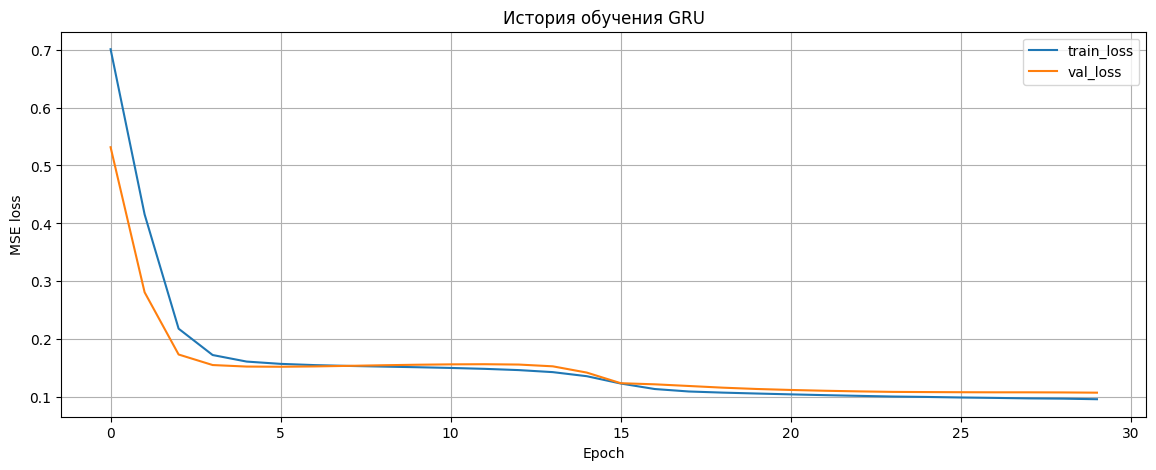

In [77]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig("artifacts/figures/gru_learning_curves.png")

In [78]:
@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


In [79]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)
val_true = inverse_scale(gru_val_true_scaled, scaler)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)

val_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(val_true, gru_val_pred)},
    ]
).sort_values("RMSE")

val_metrics

,model,MAE,RMSE,MAPE
0,GRU,4.785813,6.269294,3.266615


По метрике MAE лучшей моделью является R1

In [80]:
scaler_target = StandardScaler()
train_scaled = scaler_target.fit_transform(train_df["target"].values.reshape(-1, 1)).astype(np.float32)
val_scaled   = scaler_target.transform(val_df["target"].values.reshape(-1, 1)).astype(np.float32)
test_scaled  = scaler_target.transform(test_df["target"].values.reshape(-1, 1)).astype(np.float32)

gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)

# обратно в исходный масштаб
test_true = inverse_scale(gru_test_true_scaled, scaler_target)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler_target)

# оценка метрик
test_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(test_true, gru_test_pred)}
    ]
).sort_values("RMSE")
test_metrics


,model,MAE,RMSE,MAPE
0,GRU,5.362573,6.903608,3.48573


In [81]:
b4_val = val_metrics.rename(columns={"MAE": "MAE", "RMSE": "RMSE", "MAPE": "MAPE_%"})
b4_test = test_metrics.rename(columns={"MAE": "MAE", "RMSE": "RMSE", "MAPE": "MAPE_%"})

In [1]:
def make_run_row(
    exp_id: str,
    model_name: str,
    val_eval_df: pd.DataFrame,
    notes: str,
    test_eval_df: pd.DataFrame = None,
):
    """
    val_eval_df, test_eval_df — это результаты evaluate_regression(...) для одной модели.
    """
    row = {
        "experiment_id": exp_id,
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 19,
        "split_summary": "train=3024, val=648, test=648",
        "window_size": (
            70 if exp_id == "R1" else 
            7 if exp_id == "B2" else None
        ),
        "horizon": 1,
        "model_summary": (
            "GRU (input_size=1, hidden_size=64, num_layers=2, dropout=0.0, head=Linear)"
            if exp_id == "R1" else
            "Ridge" if exp_id == "B3" else
            "Naive (lag_1)" if exp_id == "B1" else
            "MovingAverage(7)" if exp_id == "B2" else
            model_name
        ),
        "features_summary": (
            "windowed target (no extra features)" if exp_id == "R1" else
            "lag_1,lag_7,lag_14; rolling_mean_7,rolling_std_7; dayofweek,month,hour, sin/cos"
            if exp_id == "B3" else
            "lag_1,lag_7,lag_14" if exp_id == "B1" else
            "rolling_mean_7" if exp_id == "B2" else
            "unknown"
        ),
        "scaler": "StandardScaler" if exp_id in ["B3", "R1"] else "None",
        "optimizer": "Adam" if exp_id == "R1" else "None",
        "lr": 5e-4 if exp_id == "R1" else "None",
        "epochs_trained": 30 if exp_id == "R1" else 0,
        "best_val_mae": val_eval_df["MAE"].iloc[0],
        "best_val_rmse": val_eval_df["RMSE"].iloc[0],
        "best_val_mape": val_eval_df["MAPE_%"].iloc[0],
        "test_mae": np.nan,
        "test_rmse": np.nan,
        "test_mape": np.nan,
        "notes": notes,
    }

    # если test_eval_df передан и не пустой, заполняем тестовые метрики
    if test_eval_df is not None and not test_eval_df.empty:
        row["test_mae"]   = test_eval_df["MAE"].iloc[0]
        row["test_rmse"]  = test_eval_df["RMSE"].iloc[0]
        row["test_mape"]  = test_eval_df["MAPE_%"].iloc[0]
        
    return row


In [90]:
runs = []

runs.append(make_run_row("B1", "Naive (lag_1)", b1_val, "Наивная модель ‘last value’ baseline: предсказание равно последнему наблюдённому значению (lag_1)"))
runs.append(make_run_row("B2", "MovingAverage(7)", b2_val, "Служит более сильным базовым бенчмарком, чем наивная модель, особенно если есть выраженная локальная сезонность."))
runs.append(make_run_row("B3", "Ridge", b3_val, "Использует лаги (lag_1,7,14), скользящие статистики rolling_mean_7/rolling_std_7, а также день недели, месяц, час"))
runs.append(make_run_row("R1", "GRU", b4_val, "GRU на оконном представлении временного ряда длины 70 шагов.", b4_test))

runs_df = pd.DataFrame(runs)
runs_df.to_csv("artifacts/runs.csv", index=False)

In [91]:
best_gru_path = "artifacts/best_gru.pt"
torch.save(gru_model.state_dict(), best_gru_path)

print("GRU.state_dict() сохранён:", best_gru_path)

GRU.state_dict() сохранён: artifacts/best_gru.pt


In [92]:
best_gru_config = {
    "task": "forecasting",
    "model": "GRUForecaster",
    "window_size": 28,
    "horizon": 1,
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.0,
    "batch_size": 64,
    "optimizer": "Adam",
    "lr": 5e-4,
    "epochs_trained": 30,
    "seed": 42,
    "scaler_type": "StandardScaler",
    "target_column": "target",
}

best_gru_config_path = "artifacts/best_gru_config.json"
with open(best_gru_config_path, "w", encoding="utf-8") as f:
    json.dump(best_gru_config, f, ensure_ascii=False, indent=2)

print("Конфиг GRU сохранён:", best_gru_config_path)

Конфиг GRU сохранён: artifacts/best_gru_config.json


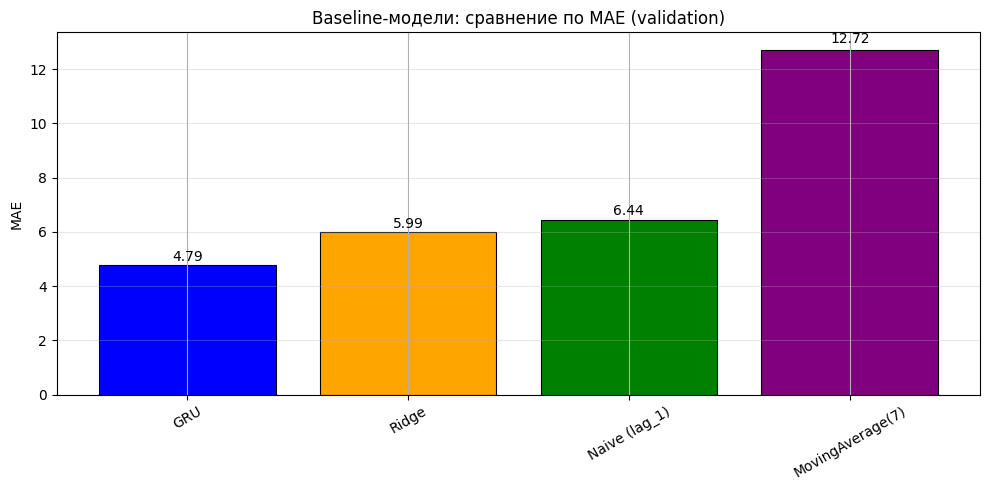

In [93]:
val_results = val_results = pd.concat([
    b1_val, b2_val, b3_val, b4_val,
], ignore_index=True).sort_values("MAE").reset_index(drop=True)
val_results_sorted = val_results.sort_values("MAE")

plt.figure(figsize=(10, 5))

bars = plt.bar(
    val_results_sorted["model"],
    val_results_sorted["MAE"],
    color=["blue", "orange", "green", "purple"],
    edgecolor="k",
    linewidth=0.8,
)

plt.title("Baseline-модели: сравнение по MAE (validation)")
plt.ylabel("MAE")
plt.xticks(rotation=30)
plt.grid(True, axis="y", alpha=0.3)

for bar, mae in zip(bars, val_results_sorted["MAE"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01 * bar.get_height(),
             f"{mae:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png")

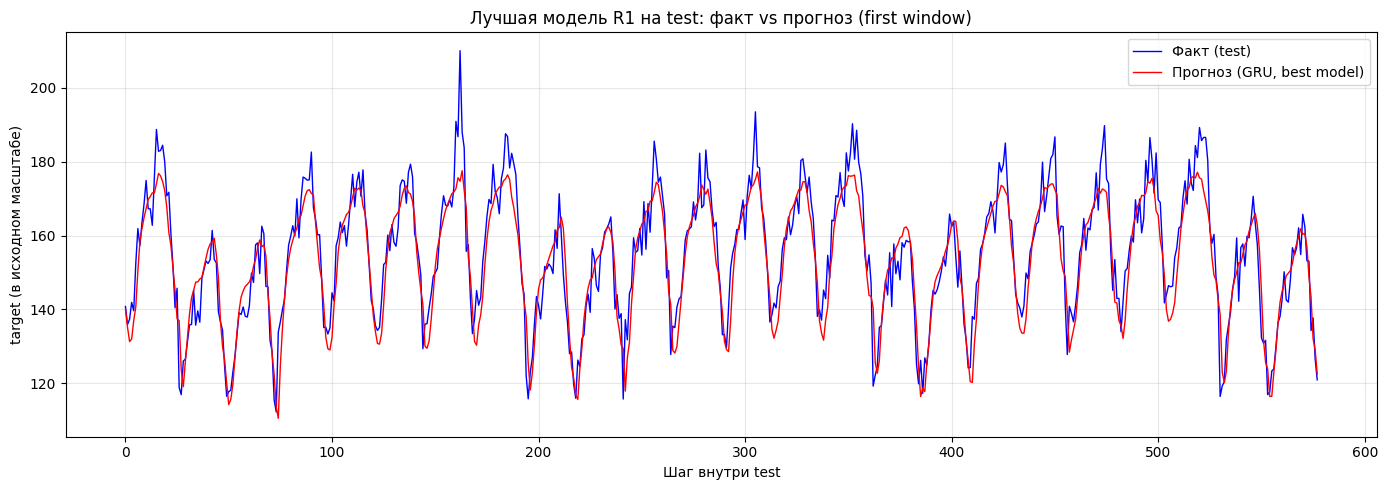

In [94]:
plt.figure(figsize=(14, 5))

plt.plot(test_true,    label="Факт (test)", c="blue", lw=1)
plt.plot(gru_test_pred, label="Прогноз (GRU, best model)", c="red", lw=1)

plt.title(f"Лучшая модель R1 на test: факт vs прогноз (first window)")
plt.xlabel("Шаг внутри test")
plt.ylabel("target (в исходном масштабе)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/figures/best_forecast_test.png")

In [95]:
import sklearn

print("pandas:", pd.__version__)
print("numpy:",  np.__version__)
print("scikit-learn:", sklearn.__version__)

pandas: 2.3.3
numpy: 2.3.4
scikit-learn: 1.8.0
